# Exercícios de Regressão Linear Simples — Resolução

Resolução dos exercícios do **Guia de Estudos - Prova.md**, seguindo o mesmo padrão de código
usado na Aula 3 (Numpy + Matplotlib, mínimos quadrados calculados na mão, sem bibliotecas prontas
de Machine Learning).

### Importação das Bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt


## Exercício 1 — Marketing x Faturamento

Uma empresa quer entender a relação entre investimento em marketing digital (milhares de R$) e
faturamento mensal (milhares de R$):

| Investimento (x) | 2 | 4 | 6 | 8 | 10 |
|---|---|---|---|---|---|
| Faturamento (y) | 35 | 45 | 75 | 85 | 110 |

**Perguntas:** a) o modelo representa bem a relação? b) qual a interpretação do coeficiente
angular? c) faturamento previsto para investimento de R$ 15 mil? d) há indícios de não-linearidade
para investimentos muito altos? e) só o marketing explica o faturamento?

#### Obtendo x e y — duas formas equivalentes

In [2]:
# Forma 1: dados digitados direto no código
x = np.array([2, 4, 6, 8, 10])
y = np.array([35, 45, 75, 85, 110])

print("x:", x)
print("y:", y)


x: [ 2  4  6  8 10]
y: [ 35  45  75  85 110]


In [3]:
# Forma 2: carregando os MESMOS dados de um arquivo CSV
# (é assim que normalmente vem na prova: os dados já prontos num arquivo)
# arquivo "exercicio1_marketing.csv":
#   investimento,faturamento
#   2,35
#   4,45
#   ...
dados = np.loadtxt("exercicio1_marketing.csv", delimiter=",", skiprows=1)
x = dados[:, 0]  # 1ª coluna do arquivo = investimento (x)
y = dados[:, 1]  # 2ª coluna do arquivo = faturamento (y)

print("x:", x)
print("y:", y)


x: [ 2.  4.  6.  8. 10.]
y: [ 35.  45.  75.  85. 110.]


In [4]:
# Calcular os coeficientes da regressão linear (m e b) pelo método dos mínimos quadrados
x_mean = np.mean(x)
y_mean = np.mean(y)

numerador = np.sum((x - x_mean) * (y - y_mean))
denominador = np.sum((x - x_mean) ** 2)
m = numerador / denominador
b = y_mean - (m * x_mean)

# Fazer as previsões do modelo e calcular o R²
y_pred = m * x + b
sqr = np.sum((y - y_pred) ** 2)  # soma quadrática dos resíduos
sqt = np.sum((y - y_mean) ** 2)  # soma quadrática total
r2 = 1 - (sqr / sqt)

print(f"Coeficiente angular (m): {m:.4f}")
print(f"Intercepto (b): {b:.4f}")
print(f"Equação da reta: faturamento = {m:.4f} * investimento + {b:.4f}")
print(f"Coeficiente de Determinação (R²): {r2:.4f}")
if r2 > 0.75:
    print("O modelo tem um bom ajuste aos dados.")
elif r2 > 0.5:
    print("O modelo tem um ajuste moderado.")
else:
    print("O modelo tem um ajuste fraco.")

# c) Previsão para um investimento de 15 mil reais
investimento_novo = 15
faturamento_previsto = m * investimento_novo + b
print(f"\nPrevisão para investimento de R$ {investimento_novo} mil: R$ {faturamento_previsto:.2f} mil")


Coeficiente angular (m): 9.5000
Intercepto (b): 13.0000
Equação da reta: faturamento = 9.5000 * investimento + 13.0000
Coeficiente de Determinação (R²): 0.9757
O modelo tem um bom ajuste aos dados.

Previsão para investimento de R$ 15 mil: R$ 155.50 mil


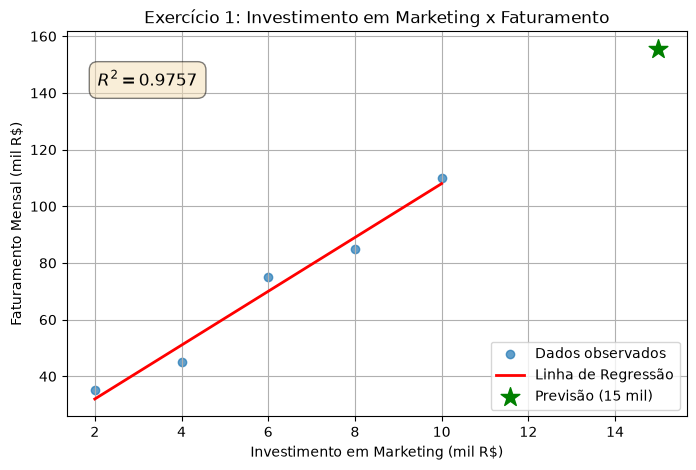

In [5]:
# Visualização dos resultados
x_line = np.array([x.min(), x.max()])
y_line = m * x_line + b

plt.figure(figsize=(8, 5))
plt.scatter(x, y, label='Dados observados', alpha=0.7)
plt.plot(x_line, y_line, color='red', linewidth=2, label='Linha de Regressão')
plt.scatter([investimento_novo], [faturamento_previsto], color='green', marker='*', s=200,
            label=f'Previsão ({investimento_novo} mil)')
plt.text(0.05, 0.9, f'$R^2 = {r2:.4f}$', transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))
plt.title("Exercício 1: Investimento em Marketing x Faturamento")
plt.xlabel("Investimento em Marketing (mil R$)")
plt.ylabel("Faturamento Mensal (mil R$)")
plt.legend()
plt.grid(True)
plt.show()


### Respostas — Exercício 1

**a)** Sim — $R^2\approx0{,}976$ é muito próximo de 1, os pontos ficam bem próximos da reta no gráfico.

**b)** $m=9{,}5$: a cada R\$ 1 mil investido a mais em marketing, o faturamento esperado aumenta em
R\$ 9,5 mil, mantendo tudo mais constante.

**c)** $9{,}5\times15+13 = \mathbf{155{,}5}$ mil reais (calculado na célula acima).

**d)** x=15 está **fora** do intervalo observado (2 a 10) — é extrapolação. Não há garantia de que
a reta continue válida; é comum que o retorno de marketing sature em investimentos muito altos
(retornos marginais decrescentes).

**e)** Não — fatores como sazonalidade, concorrência, preço, qualidade do produto etc. também
afetam o faturamento; um modelo mais realista usaria Regressão Múltipla.

## Exercício 2 — Experiência x Salário

RH quer prever o salário médio (mil R$) a partir dos anos de experiência:

| Experiência (x) | 1 | 3 | 5 | 7 | 9 |
|---|---|---|---|---|---|
| Salário (y) | 3 | 4 | 6 | 7 | 10 |

**Perguntas:** a) existe tendência linear clara? b) interpretação do coeficiente angular?
c) salário previsto para 25 anos de experiência (faz sentido)? d) há sinais de progressão não
linear? e) limitações de usar só "anos de experiência" como variável?

#### Obtendo x e y — duas formas equivalentes

In [6]:
# Forma 1: dados digitados direto no código
x = np.array([1, 3, 5, 7, 9])
y = np.array([3, 4, 6, 7, 10])

print("x:", x)
print("y:", y)


x: [1 3 5 7 9]
y: [ 3  4  6  7 10]


In [7]:
# Forma 2: carregando os MESMOS dados de um arquivo CSV
# arquivo "exercicio2_experiencia.csv":
#   experiencia,salario
#   1,3
#   3,4
#   ...
dados = np.loadtxt("exercicio2_experiencia.csv", delimiter=",", skiprows=1)
x = dados[:, 0]  # 1ª coluna do arquivo = experiência (x)
y = dados[:, 1]  # 2ª coluna do arquivo = salário (y)

print("x:", x)
print("y:", y)


x: [1. 3. 5. 7. 9.]
y: [ 3.  4.  6.  7. 10.]


In [8]:
x_mean = np.mean(x)
y_mean = np.mean(y)

numerador = np.sum((x - x_mean) * (y - y_mean))
denominador = np.sum((x - x_mean) ** 2)
m = numerador / denominador
b = y_mean - (m * x_mean)

y_pred = m * x + b
sqr = np.sum((y - y_pred) ** 2)
sqt = np.sum((y - y_mean) ** 2)
r2 = 1 - (sqr / sqt)

print(f"Coeficiente angular (m): {m:.4f}")
print(f"Intercepto (b): {b:.4f}")
print(f"Equação da reta: salario = {m:.4f} * experiencia + {b:.4f}")
print(f"Coeficiente de Determinação (R²): {r2:.4f}")
if r2 > 0.75:
    print("O modelo tem um bom ajuste aos dados.")
elif r2 > 0.5:
    print("O modelo tem um ajuste moderado.")
else:
    print("O modelo tem um ajuste fraco.")

# c) Previsão para 25 anos de experiência
experiencia_nova = 25
salario_previsto = m * experiencia_nova + b
print(f"\nPrevisão para {experiencia_nova} anos de experiência: R$ {salario_previsto:.2f} mil")
print("Atenção: 25 anos está bem fora do intervalo observado (1 a 9 anos) -> é uma extrapolação.")


Coeficiente angular (m): 0.8500
Intercepto (b): 1.7500
Equação da reta: salario = 0.8500 * experiencia + 1.7500
Coeficiente de Determinação (R²): 0.9633
O modelo tem um bom ajuste aos dados.

Previsão para 25 anos de experiência: R$ 23.00 mil
Atenção: 25 anos está bem fora do intervalo observado (1 a 9 anos) -> é uma extrapolação.


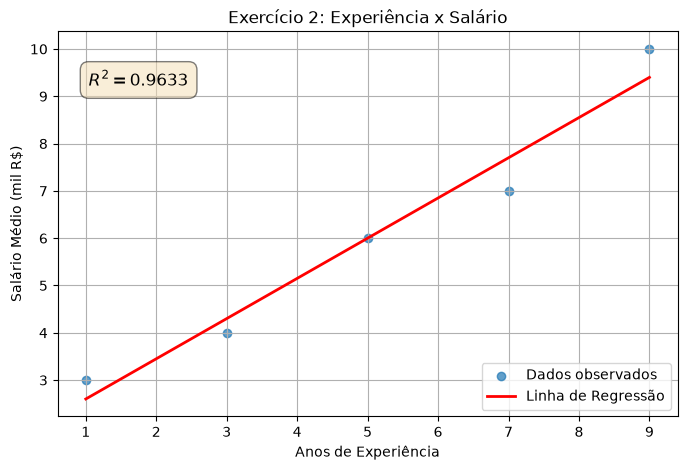

In [9]:
# Visualização dos resultados
x_line = np.array([x.min(), x.max()])
y_line = m * x_line + b

plt.figure(figsize=(8, 5))
plt.scatter(x, y, label='Dados observados', alpha=0.7)
plt.plot(x_line, y_line, color='red', linewidth=2, label='Linha de Regressão')
plt.text(0.05, 0.9, f'$R^2 = {r2:.4f}$', transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))
plt.title("Exercício 2: Experiência x Salário")
plt.xlabel("Anos de Experiência")
plt.ylabel("Salário Médio (mil R$)")
plt.legend()
plt.grid(True)
plt.show()


### Respostas — Exercício 2

**a)** Sim, tendência linear forte ($R^2\approx0{,}963$).

**b)** A cada ano a mais de experiência, o salário médio previsto sobe R\$ 850 (0,85 mil), tudo
mais constante.

**c)** $0{,}85\times25+1{,}75 = \mathbf{23{,}0}$ mil reais (calculado na célula acima). Não é
muito realista: 25 está bem fora do intervalo observado (1 a 9 anos) — extrapolação longa.

**d)** Na prática, salários costumam **desacelerar** (não crescer linearmente para sempre); um
modelo linear tende a superestimar salários de profissionais muito experientes.

**e)** Não considera cargo, empresa, formação, região, negociação individual etc. — pediria
Regressão Múltipla.

## Exercício 3 — Treinamentos x Produtividade

Gestor de RH quer relacionar nº de treinamentos técnicos no ano com a produtividade média mensal
(0 a 100 pontos):

| Treinamentos (x) | 0 | 5 | 10 | 15 | 20 |
|---|---|---|---|---|---|
| Produtividade (y) | 50 | 65 | 70 | 80 | 90 |

**Perguntas:** a) há relação linear clara? b) interpretação do coeficiente angular? c) produtividade
prevista para 20 treinamentos? d) produtividade inicial (0 treinamentos) é realista? e) o ganho se
estabiliza? f) diferença de produtividade entre 5 e 15 treinamentos? g) outras variáveis relevantes?

#### Obtendo x e y — duas formas equivalentes

In [10]:
# Forma 1: dados digitados direto no código
x = np.array([0, 5, 10, 15, 20])
y = np.array([50, 65, 70, 80, 90])

print("x:", x)
print("y:", y)


x: [ 0  5 10 15 20]
y: [50 65 70 80 90]


In [11]:
# Forma 2: carregando os MESMOS dados de um arquivo CSV
# arquivo "exercicio3_treinamentos.csv":
#   treinamentos,produtividade
#   0,50
#   5,65
#   ...
dados = np.loadtxt("exercicio3_treinamentos.csv", delimiter=",", skiprows=1)
x = dados[:, 0]  # 1ª coluna do arquivo = treinamentos (x)
y = dados[:, 1]  # 2ª coluna do arquivo = produtividade (y)

print("x:", x)
print("y:", y)


x: [ 0.  5. 10. 15. 20.]
y: [50. 65. 70. 80. 90.]


In [12]:
x_mean = np.mean(x)
y_mean = np.mean(y)

numerador = np.sum((x - x_mean) * (y - y_mean))
denominador = np.sum((x - x_mean) ** 2)
m = numerador / denominador
b = y_mean - (m * x_mean)

y_pred = m * x + b
sqr = np.sum((y - y_pred) ** 2)
sqt = np.sum((y - y_mean) ** 2)
r2 = 1 - (sqr / sqt)

print(f"Coeficiente angular (m): {m:.4f}")
print(f"Intercepto (b): {b:.4f}")
print(f"Equação da reta: produtividade = {m:.4f} * treinamentos + {b:.4f}")
print(f"Coeficiente de Determinação (R²): {r2:.4f}")
if r2 > 0.75:
    print("O modelo tem um bom ajuste aos dados.")
elif r2 > 0.5:
    print("O modelo tem um ajuste moderado.")
else:
    print("O modelo tem um ajuste fraco.")

# c) Previsão para 20 treinamentos
treinamentos_novo = 20
produtividade_prevista = m * treinamentos_novo + b
print(f"\nPrevisão para {treinamentos_novo} treinamentos: {produtividade_prevista:.2f} pontos")

# f) Diferença de produtividade entre 15 e 5 treinamentos
diferenca = (m * 15 + b) - (m * 5 + b)
print(f"Diferença de produtividade entre 15 e 5 treinamentos: {diferenca:.2f} pontos")


Coeficiente angular (m): 1.9000
Intercepto (b): 52.0000
Equação da reta: produtividade = 1.9000 * treinamentos + 52.0000
Coeficiente de Determinação (R²): 0.9810
O modelo tem um bom ajuste aos dados.

Previsão para 20 treinamentos: 90.00 pontos
Diferença de produtividade entre 15 e 5 treinamentos: 19.00 pontos


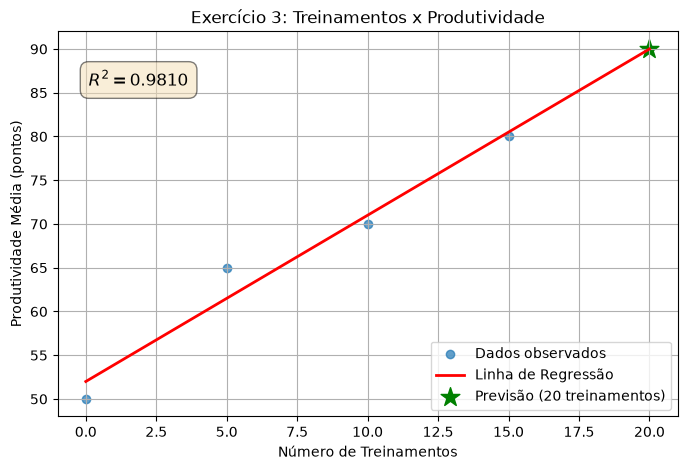

In [13]:
# Visualização dos resultados
x_line = np.array([x.min(), x.max()])
y_line = m * x_line + b

plt.figure(figsize=(8, 5))
plt.scatter(x, y, label='Dados observados', alpha=0.7)
plt.plot(x_line, y_line, color='red', linewidth=2, label='Linha de Regressão')
plt.scatter([treinamentos_novo], [produtividade_prevista], color='green', marker='*', s=200,
            label=f'Previsão ({treinamentos_novo} treinamentos)')
plt.text(0.05, 0.9, f'$R^2 = {r2:.4f}$', transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))
plt.title("Exercício 3: Treinamentos x Produtividade")
plt.xlabel("Número de Treinamentos")
plt.ylabel("Produtividade Média (pontos)")
plt.legend()
plt.grid(True)
plt.show()


### Respostas — Exercício 3

**a)** Sim, relação linear muito forte ($R^2\approx0{,}981$).

**b)** Cada treinamento adicional aumenta a produtividade média prevista em 1,9 ponto.

**c)** $1{,}9\times20+52=\mathbf{90}$ pontos (calculado na célula acima).

**d)** Intercepto $b=52$: produtividade prevista sem nenhum treinamento é 52 pontos — plausível
(funcionário já tem alguma produtividade base sem treinamento).

**e)** O modelo linear, por construção, diz que o ganho é constante e infinito — mas na prática é
comum esse ganho se estabilizar (retornos marginais decrescentes); dentro do intervalo observado
(0–20) o ajuste linear é bom, extrapolar para muito além disso é arriscado.

**f)** Diferença de **19 pontos** de produtividade entre 15 e 5 treinamentos (calculado na célula
acima). Se o custo dos 10 treinamentos extras for menor que o valor gerado por 19 pontos a mais de
produtividade, compensa (depende do contexto de custo/benefício da empresa).

**g)** Motivação, tipo/qualidade do treinamento, experiência prévia, ferramentas disponíveis,
carga de trabalho, etc.